In [ ]:
#observation 1 to 5 Stats 

In [53]:
# ============================================================
# RQ1 (Merged) — Stats calculator for Observations 1.4
# Dataset: 5_Total_Repo.csv (repo-level master)
# ============================================================

from __future__ import annotations

import math
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy import stats


# -----------------------------
# Config
# -----------------------------
ROOT_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT_DIR / "5_Total_Repo.csv"

ADOPT_COL = "instru_t_ci_signal"   # 'True'/'False'
LANG_COL  = "language"
ENV_COL   = "Exec_Env_Style"       # comma-separated multi-label; blank = Unclassified (for adopters)
INV_COL   = "Test_Inv_Style"       # comma-separated; blank = Unobserved (for adopters)

CI_COLS = ["github_actions", "travis_ci", "circle_ci", "gitlab"]  # numeric counts; treat >0 as present

# For activity/age comparisons (Obs 1.5)
PR_COL   = "pull_requests"
COMMITS_COL = "local_commit_count"   # matches earlier repo-level commit measure
AGE_COL  = "repo_age"                # years (float)


# -----------------------------
# Helpers: stats / parsing
# -----------------------------
def _to_bool_str(x) -> str:
    """Normalize various truthy representations to 'True'/'False' strings."""
    if isinstance(x, bool):
        return "True" if x else "False"
    s = str(x).strip()
    if s.lower() in {"true", "1", "yes", "y", "t"}:
        return "True"
    return "False"

def cohen_h(p1: float, p2: float) -> float:
    """Cohen's h for difference in proportions."""
    # h = 2*arcsin(sqrt(p1)) - 2*arcsin(sqrt(p2))
    p1 = min(max(p1, 0.0), 1.0)
    p2 = min(max(p2, 0.0), 1.0)
    return 2.0 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))

def cramers_v(chi2: float, n: int, r: int, c: int) -> float:
    """Cramér’s V for an r x c contingency table."""
    if n <= 0:
        return float("nan")
    k = min(r - 1, c - 1)
    if k <= 0:
        return float("nan")
    return math.sqrt(chi2 / (n * k))

def phi_from_chi2(chi2: float, n: int) -> float:
    """Phi for 2x2 tables."""
    if n <= 0:
        return float("nan")
    return math.sqrt(chi2 / n)

def cliffs_delta_from_u(U: float, n1: int, n2: int) -> float:
    """
    Cliff's delta via Mann-Whitney U.
    With SciPy's U (wins + 0.5 ties), delta = (2U/(n1*n2)) - 1.
    """
    if n1 <= 0 or n2 <= 0:
        return float("nan")
    return (2.0 * U / (n1 * n2)) - 1.0

def parse_multilabel(cell: str) -> List[str]:
    """Comma-separated labels -> list of cleaned labels."""
    if cell is None:
        return []
    s = str(cell).strip()
    if not s:
        return []
    return [p.strip() for p in s.split(",") if p.strip()]

def normalize_env_labels(raw_list: List[str]) -> List[str]:
    """Map dataset env labels to paper labels."""
    mapped = []
    for x in raw_list:
        if x == "Emu_Community":
            mapped.append("Community")
        elif x == "Emu_Custom":
            mapped.append("Custom")
        elif x in {"Emu_GMD", "GMD"}:
            mapped.append("GMD")
        elif x in {"Third-Party", "Third Party", "ThirdParty"}:
            mapped.append("Third Party")
        elif x in {"Real Device", "RealDevice"}:
            mapped.append("Real Device")
        else:
            # unknown label: keep as-is (useful for debugging)
            mapped.append(x)
    return mapped

def env_style_set(row: pd.Series) -> List[str]:
    """Return normalized env style list. Blank => [] (later treated as Unclassified if adopter)."""
    return normalize_env_labels(parse_multilabel(row.get(ENV_COL, "")))

def inv_style_set(row: pd.Series) -> List[str]:
    """Return invocation style list. Blank => [] (later treated as Unobserved)."""
    return parse_multilabel(row.get(INV_COL, ""))

def as_numeric(s: pd.Series, fill: float = np.nan) -> pd.Series:
    out = pd.to_numeric(s, errors="coerce")
    if not np.isnan(fill):
        out = out.fillna(fill)
    return out

def binary_present(series: pd.Series) -> pd.Series:
    """CI footprint: numeric count > 0 => 1 else 0."""
    x = pd.to_numeric(series, errors="coerce").fillna(0.0)
    return (x > 0).astype(int)


# -----------------------------
# Load
# -----------------------------
def load_main_dataset() -> pd.DataFrame:
    if not MAIN_CSV.exists():
        raise FileNotFoundError(f"Missing main CSV: {MAIN_CSV}")
    df = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8")
    # Normalize adopter flag
    df[ADOPT_COL] = df[ADOPT_COL].apply(_to_bool_str)
    return df


# ============================================================
# Observation 1.1 — Adoption rate
# ============================================================
def obs_1_1_adoption_rate(df: pd.DataFrame) -> Dict:
    n = len(df)
    adopters = int((df[ADOPT_COL] == "True").sum())
    rate = adopters / n if n else float("nan")
    return {
        "N_total": n,
        "N_adopters": adopters,
        "adoption_rate": rate,
    }


# ============================================================
# Observation 1.2 — Kotlin/Java vs C/C++ adoption gap
# (chi-square + Cohen's h)
# ============================================================
def obs_1_2_language_gap(df: pd.DataFrame) -> Dict:
    langs_kj = {"Kotlin", "Java"}
    langs_ccpp = {"C", "C++", "Objective-C", "Objective-C++"}

    # Filter rows with language in either bucket
    sub = df[df[LANG_COL].isin(langs_kj.union(langs_ccpp))].copy()
    sub["bucket"] = np.where(sub[LANG_COL].isin(langs_kj), "Kotlin+Java", "C/C++")
    sub["adopt"] = (sub[ADOPT_COL] == "True").astype(int)

    # Counts
    counts = sub.groupby("bucket")["adopt"].agg(["sum", "count"]).rename(columns={"sum": "adopters", "count": "total"})
    a1 = int(counts.loc["Kotlin+Java", "adopters"])
    n1 = int(counts.loc["Kotlin+Java", "total"])
    a2 = int(counts.loc["C/C++", "adopters"])
    n2 = int(counts.loc["C/C++", "total"])

    p1 = a1 / n1 if n1 else float("nan")
    p2 = a2 / n2 if n2 else float("nan")

    # 2x2 table: bucket x adoption
    # rows: Kotlin+Java, C/C++
    # cols: adopter(1), non-adopter(0)
    table = np.array([
        [a1, n1 - a1],
        [a2, n2 - a2],
    ], dtype=int)

    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)
    h = cohen_h(p1, p2)

    return {
        "bucket_counts": counts,
        "table_2x2": table,
        "chi2": chi2,
        "p_value": p,
        "cohens_h": h,
        "p_kotlin_java": p1,
        "p_ccpp": p2,
    }


# ============================================================
# Observation 1.3 — Environment styles among adopters
# ============================================================
def obs_1_3_env_distribution(df: pd.DataFrame) -> Dict:
    adopters = df[df[ADOPT_COL] == "True"].copy()
    n = len(adopters)

    any_use = {k: 0 for k in ["Community", "Custom", "GMD", "Third Party", "Real Device", "Unclassified"]}
    single_style = 0
    mixed_style = 0

    for _, row in adopters.iterrows():
        styles = env_style_set(row)
        if not styles:
            # adopter but no env signal in artifacts
            styles = ["Unclassified"]

        uniq = sorted(set(styles))
        for s in uniq:
            if s not in any_use:
                any_use[s] = 0
            any_use[s] += 1

        if len(uniq) == 1:
            single_style += 1
        else:
            mixed_style += 1

    any_use_df = (
        pd.DataFrame([{"style": k, "count": v, "pct_of_adopters": (v / n * 100.0 if n else np.nan)} for k, v in any_use.items()])
        .sort_values(["count", "style"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return {
        "N_adopters": n,
        "any_use": any_use_df,
        "single_style_repos": single_style,
        "mixed_style_repos": mixed_style,
        "single_style_pct": (single_style / n * 100.0 if n else np.nan),
        "mixed_style_pct": (mixed_style / n * 100.0 if n else np.nan),
    }


# ============================================================
# Observation 1.4 — Test invocation styles among adopters
# ============================================================
def obs_1_4_invocation_distribution(df: pd.DataFrame) -> Dict:
    adopters = df[df[ADOPT_COL] == "True"].copy()
    n = len(adopters)

    any_use = {k: 0 for k in ["Gradle-based", "Third-Party CLI", "ADB", "Unobserved"]}
    mixed_invocation = 0
    observable = 0

    for _, row in adopters.iterrows():
        inv = inv_style_set(row)
        if not inv:
            inv = ["Unobserved"]
        else:
            observable += 1

        uniq = sorted(set(inv))
        for s in uniq:
            if s not in any_use:
                any_use[s] = 0
            any_use[s] += 1

        if len(uniq) >= 2:
            mixed_invocation += 1

    any_use_df = (
        pd.DataFrame([{"invocation": k, "count": v, "pct_of_adopters": (v / n * 100.0 if n else np.nan)} for k, v in any_use.items()])
        .sort_values(["count", "invocation"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return {
        "N_adopters": n,
        "observable_invocation_repos": observable,
        "observable_pct": (observable / n * 100.0 if n else np.nan),
        "mixed_invocation_repos": mixed_invocation,
        "mixed_invocation_pct": (mixed_invocation / n * 100.0 if n else np.nan),
        "any_use": any_use_df,
    }


# ============================================================
# Observation 1.5 — Style ↔ CI provider coupling (chi-square + V)
#                + Community vs Custom activity/age (MWU + Cliff’s δ)
# ============================================================
def obs_1_5_style_coupling_and_strata(df: pd.DataFrame) -> Dict:
    adopters = df[df[ADOPT_COL] == "True"].copy()

    # --- Build single-style adopter subset (exclude Real Device like the paper table) ---
    def single_style_label(row) -> str:
        styles = env_style_set(row)
        if not styles:
            return "Unclassified"
        uniq = sorted(set(styles))
        if len(uniq) == 1:
            return uniq[0]
        return "Mixed"

    adopters["env_single"] = adopters.apply(single_style_label, axis=1)
    single = adopters[(adopters["env_single"] != "Mixed") & (adopters["env_single"] != "Real Device")].copy()

    # Sanity: expected ~457 (459 single-style minus 2 Real Device)
    n_single = len(single)

    # --- (A) CI provider coupling: for each CI service column, style x present(0/1) ---
    ci_results = []
    style_order = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]
    single["env_single"] = pd.Categorical(single["env_single"], categories=style_order, ordered=True)

    for col in CI_COLS:
        if col not in single.columns:
            continue
        present = binary_present(single[col])
        ct = pd.crosstab(single["env_single"], present)  # rows: style, cols: 0/1
        # Ensure both columns exist
        if 0 not in ct.columns:
            ct[0] = 0
        if 1 not in ct.columns:
            ct[1] = 0
        ct = ct[[0, 1]]

        chi2, p, dof, exp = stats.chi2_contingency(ct.values, correction=False)
        V = cramers_v(chi2, int(ct.values.sum()), ct.shape[0], ct.shape[1])

        ci_results.append({
            "ci_service": col,
            "N": int(ct.values.sum()),
            "chi2": chi2,
            "p_value": p,
            "cramers_V": V,
            "contingency": ct
        })

    # --- (B) Community vs Custom strata: MWU + Cliff’s delta on PRs, commits, age ---
    cc = single[single["env_single"] == "Community"].copy()
    cu = single[single["env_single"] == "Custom"].copy()

    # Convert to numeric
    cc_pr = as_numeric(cc.get(PR_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()
    cu_pr = as_numeric(cu.get(PR_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()

    cc_cm = as_numeric(cc.get(COMMITS_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()
    cu_cm = as_numeric(cu.get(COMMITS_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()

    cc_age = as_numeric(cc.get(AGE_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()
    cu_age = as_numeric(cu.get(AGE_COL, pd.Series([], dtype=str)), fill=np.nan).dropna().to_numpy()

    # One-sided MWU:
    # - PRs: Community > Custom
    U_pr, p_pr = stats.mannwhitneyu(cc_pr, cu_pr, alternative="greater", method="asymptotic")
    d_pr = cliffs_delta_from_u(U_pr, len(cc_pr), len(cu_pr))

    # - Commits: Community > Custom
    U_cm, p_cm = stats.mannwhitneyu(cc_cm, cu_cm, alternative="greater", method="asymptotic")
    d_cm = cliffs_delta_from_u(U_cm, len(cc_cm), len(cu_cm))

    # - Age: Community < Custom  (so test Custom > Community OR Community < Custom)
    U_age, p_age = stats.mannwhitneyu(cc_age, cu_age, alternative="less", method="asymptotic")
    d_age = cliffs_delta_from_u(U_age, len(cc_age), len(cu_age))  # delta is for first sample (Community)

    strata = {
        "N_single_style_excl_realdevice": n_single,
        "Community_n": len(cc),
        "Custom_n": len(cu),

        "pull_requests": {
            "median_community": float(np.nanmedian(cc_pr)) if len(cc_pr) else np.nan,
            "median_custom": float(np.nanmedian(cu_pr)) if len(cu_pr) else np.nan,
            "p_one_sided": float(p_pr),
            "cliffs_delta": float(d_pr),  # + => Community tends larger
        },
        "commits": {
            "median_community": float(np.nanmedian(cc_cm)) if len(cc_cm) else np.nan,
            "median_custom": float(np.nanmedian(cu_cm)) if len(cu_cm) else np.nan,
            "p_one_sided": float(p_cm),
            "cliffs_delta": float(d_cm),
        },
        "repo_age_years": {
            "median_community": float(np.nanmedian(cc_age)) if len(cc_age) else np.nan,
            "median_custom": float(np.nanmedian(cu_age)) if len(cu_age) else np.nan,
            "p_one_sided": float(p_age),
            "cliffs_delta": float(d_age),  # negative => Community tends smaller (younger)
        },
    }

    return {
        "ci_coupling": ci_results,
        "community_vs_custom": strata,
    }


# -----------------------------
# Pretty printing helpers
# -----------------------------
def print_header(title: str):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)

def fmt_pct(x: float) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    return f"{x*100:.1f}%" if x <= 1.0 else f"{x:.1f}%"


# -----------------------------
# Main runner
# -----------------------------
def main():
    df = load_main_dataset()

    # Obs 1.1
    print_header("Observation 1.1 — Adoption rate")
    r = obs_1_1_adoption_rate(df)
    print(f"N_total = {r['N_total']}")
    print(f"N_adopters = {r['N_adopters']}")
    print(f"Adoption rate = {r['adoption_rate']:.4f} ({r['adoption_rate']*100:.1f}%)")

    # Obs 1.2
    print_header("Observation 1.2 — Kotlin+Java vs C/C++ adoption gap (chi2 + Cohen's h)")
    r = obs_1_2_language_gap(df)
    print(r["bucket_counts"])
    print("2x2 table [[KJ_adopt, KJ_non], [CCPP_adopt, CCPP_non]]:")
    print(r["table_2x2"])
    print(f"chi2 = {r['chi2']:.2f}, p = {r['p_value']:.3g}, Cohen's h = {r['cohens_h']:.2f}")
    print(f"p(Kotlin+Java) = {r['p_kotlin_java']:.4f}, p(C/C++) = {r['p_ccpp']:.4f}")

    # Obs 1.3
    print_header("Observation 1.3 — Execution-environment distribution among adopters")
    r = obs_1_3_env_distribution(df)
    print(f"N_adopters = {r['N_adopters']}")
    print(r["any_use"])
    print(f"Single-style repos = {r['single_style_repos']} ({r['single_style_pct']:.1f}%)")
    print(f"Mixed-style repos  = {r['mixed_style_repos']} ({r['mixed_style_pct']:.1f}%)")


    # Obs 1.4
    print_header("Observation 1.4 — Style↔CI coupling + Community vs Custom strata")
    r = obs_1_5_style_coupling_and_strata(df)

    print("\n(A) CI coupling (style x CI-service presence):")
    for item in r["ci_coupling"]:
        print(f"\nService: {item['ci_service']}")
        print(item["contingency"])
        print(f"chi2 = {item['chi2']:.2f}, p = {item['p_value']:.3g}, Cramer's V = {item['cramers_V']:.3f}")
    print("Column 0 = repos in that style where github_actions is not present (<=0 or blank)\nColumn 1 = repos in that style where github_actions is present (>0)")

    print("\n(B) Community vs Custom (single-style, excl Real Device):")
    s = r["community_vs_custom"]
    print(f"N single-style excl Real Device = {s['N_single_style_excl_realdevice']}")
    print(f"Community n = {s['Community_n']}, Custom n = {s['Custom_n']}")

    for k in ["pull_requests", "commits", "repo_age_years"]:
        d = s[k]
        print(f"\n{k}:")
        print(f"  median Community = {d['median_community']:.2f}")
        print(f"  median Custom    = {d['median_custom']:.2f}")
        print(f"  one-sided p      = {d['p_one_sided']:.3g}")
        print(f"  Cliff's delta    = {d['cliffs_delta']:.3f}")

    # Obs 1.5
    print_header("Observation 1.5 — Invocation distribution among adopters")
    r = obs_1_4_invocation_distribution(df)
    print(f"N_adopters = {r['N_adopters']}")
    print(f"Invocation observable = {r['observable_invocation_repos']} ({r['observable_pct']:.1f}%)")
    print(r["any_use"])
    print(f"Mixed-invocation repos = {r['mixed_invocation_repos']} ({r['mixed_invocation_pct']:.1f}%)")

if __name__ == "__main__":
    main()



Observation 1.1 — Adoption rate
N_total = 4518
N_adopters = 481
Adoption rate = 0.1065 (10.6%)

Observation 1.2 — Kotlin+Java vs C/C++ adoption gap (chi2 + Cohen's h)
             adopters  total
bucket                      
C/C++              10    365
Kotlin+Java       386   2886
2x2 table [[KJ_adopt, KJ_non], [CCPP_adopt, CCPP_non]]:
[[ 386 2500]
 [  10  355]]
chi2 = 34.26, p = 4.82e-09, Cohen's h = 0.42
p(Kotlin+Java) = 0.1337, p(C/C++) = 0.0274

Observation 1.3 — Execution-environment distribution among adopters
N_adopters = 481
          style  count  pct_of_adopters
0     Community    251        52.182952
1        Custom    150        31.185031
2  Unclassified     51        10.602911
3   Third Party     32         6.652807
4           GMD     16         3.326403
5   Real Device      2         0.415800
Single-style repos = 460 (95.6%)
Mixed-style repos  = 21 (4.4%)

Observation 1.4 — Style↔CI coupling + Community vs Custom strata

(A) CI coupling (style x CI-service presence):



In [ ]:
#Tables and Visualizations

[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs15_ci_footprint_stacked.csv
              GitHub Actions  Travis CI  CircleCI  GitLab CI
Community               93.9        2.5       3.3        0.4
Custom                  11.6       74.8      11.6        1.9
GMD                     85.7        0.0       0.0       14.3
Third Party             60.7        7.1      32.1        0.0
Unclassified            50.0       40.4       1.9        7.7
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs15_ci_footprint_stacked.png


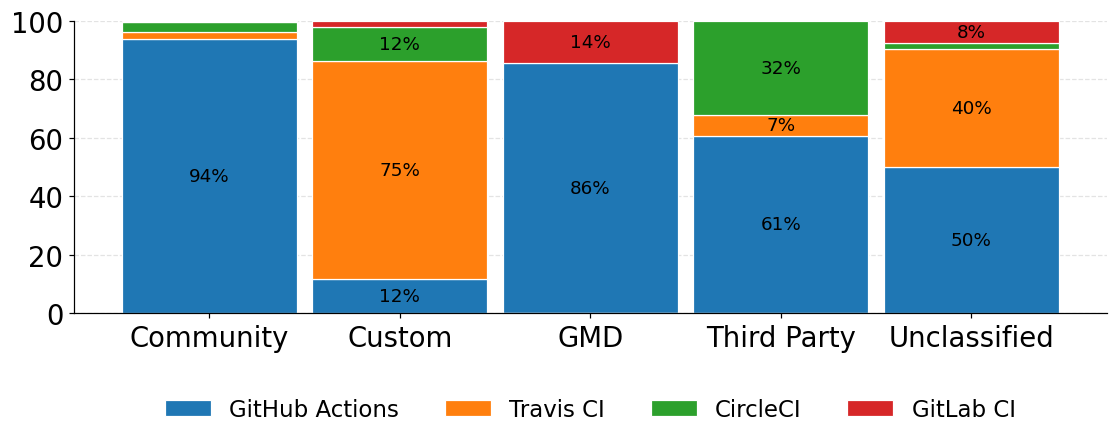

In [23]:
# ============================================================
# RQ1 / Observation 1.4 — Stacked bars: CI footprint by env style
# ============================================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT / "5_Total_Repo.csv"

OUT_DIR = ROOT / "RQ1_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq1_obs15_ci_footprint_stacked.png"
OUT_CSV = OUT_DIR / "rq1_obs15_ci_footprint_stacked.csv"

ADOPT_COL = "instru_t_ci_signal"
ENV_COL   = "Exec_Env_Style"
CI_COLS   = {
    "GitHub Actions": "github_actions",
    "Travis CI": "travis_ci",
    "CircleCI": "circle_ci",
    "GitLab CI": "gitlab",
}

STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]

def _to_bool_str(x) -> str:
    s = str(x).strip().lower()
    return "true" if s in {"true", "1", "yes", "y", "t"} else "false"

def parse_multilabel(cell: str) -> list[str]:
    s = str(cell).strip() if cell is not None else ""
    return [p.strip() for p in s.split(",") if p.strip()] if s else []

def normalize_env_labels(raw: list[str]) -> list[str]:
    m = []
    for x in raw:
        if x == "Emu_Community":
            m.append("Community")
        elif x == "Emu_Custom":
            m.append("Custom")
        elif x in {"GMD", "Emu_GMD"}:
            m.append("GMD")
        elif x in {"ThirdParty", "ThirdPartyDeviceLab", "Third Party", "Third-Party"}:
            m.append("Third Party")
        elif x in {"Real Device", "RealDevice"}:
            m.append("Real Device")
        else:
            m.append(x)
    return m

def single_style_label(env_cell: str) -> str:
    styles = normalize_env_labels(parse_multilabel(env_cell))
    styles = sorted(set([s for s in styles if s]))
    if not styles:
        return "Unclassified"
    if len(styles) == 1:
        return styles[0]
    return "Mixed"

def binary_present(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").fillna(0.0)
    return (x > 0).astype(int)

# ---- Load ----
if not MAIN_CSV.exists():
    raise FileNotFoundError(f"Missing: {MAIN_CSV}")

df = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8").copy()
df[ADOPT_COL] = df[ADOPT_COL].apply(_to_bool_str)

adopters = df[df[ADOPT_COL] == "true"].copy()
adopters["env_single"] = adopters[ENV_COL].apply(single_style_label)
# Drop Unclassified (missing execution-style evidence)
adopters = adopters[adopters["env_single"] != "Unclassified"].copy()


# single-style only, exclude Mixed and Real Device (per paper)
adopters = adopters[(adopters["env_single"] != "Mixed") & (adopters["env_single"] != "Real Device")].copy()

# map unknown/noisy to Unclassified
adopters.loc[~adopters["env_single"].isin(STYLE_ORDER), "env_single"] = "Unclassified"

# ---- Build footprint counts per style x CI service ----
style_service_counts = pd.DataFrame(index=STYLE_ORDER, columns=list(CI_COLS.keys()), data=0.0)

for service_name, col in CI_COLS.items():
    if col not in adopters.columns:
        raise ValueError(f"Missing CI column '{col}' for service '{service_name}' in {MAIN_CSV.name}")
    adopters[service_name] = binary_present(adopters[col])

for style in STYLE_ORDER:
    sub = adopters[adopters["env_single"] == style]
    for service_name in CI_COLS.keys():
        style_service_counts.loc[style, service_name] = float(sub[service_name].sum())

# Convert to footprint-share (each bar sums to 100%)
footprint_totals = style_service_counts.sum(axis=1).replace(0.0, np.nan)
style_service_share = (style_service_counts.div(footprint_totals, axis=0) * 100.0).fillna(0.0)

style_service_share.to_csv(OUT_CSV, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(style_service_share.round(1))

# ---- Plot (DISPLAY + SAVE) ----
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 18,
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "legend.fontsize": 15,
})

fig, ax = plt.subplots(figsize=(10.5, 4.2))

style_service_share.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.92,
    edgecolor="white",
    linewidth=0.8,
)

#ax.set_ylabel("Share of CI-service footprint (%)")
#ax.set_xlabel("Execution-environment style (single-style adopters)")
ax.set_ylim(0, 100)

# Horizontal x labels
ax.tick_params(axis="x", labelrotation=0)
for lab in ax.get_xticklabels():
    lab.set_ha("center")

# Subtle y-grid (helps readability)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ----------------------------
# NEW: add % labels per segment
# ----------------------------
LABEL_MIN_PCT = 6.0   # label only segments >= this % (reduce clutter)
for container in ax.containers:
    labels = []
    for patch in container:
        h = patch.get_height()
        if h >= LABEL_MIN_PCT:
            labels.append(f"{h:.0f}%")
        else:
            labels.append("")  # no label
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=12,
    )

# Legend below, centered (no title)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=len(CI_COLS),
    frameon=False,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)

plt.savefig(OUT_PNG, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")

plt.show()


In [ ]:
#heatmap

[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_ci_footprint_heatmap.csv
              GitHub Actions  Travis CI  CircleCI  GitLab CI  Other
Community               93.5        2.4       3.3        0.4    0.4
Custom                  11.1       71.6      11.1        1.9    4.3
GMD                     85.7        0.0       0.0       14.3    0.0
Third Party             54.8        6.5      29.0        0.0    9.7
Unclassified            47.3       38.2       1.8        7.3    5.5
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_ci_footprint_heatmap.png


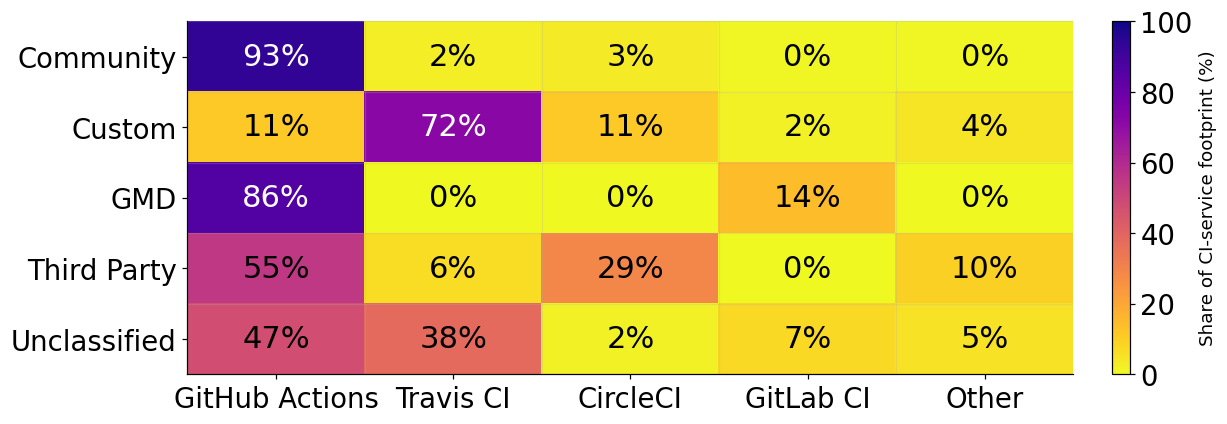

In [42]:
# ============================================================
# RQ1 / Observation 1.4 — Heatmap: CI footprint-share by env style
#   - Shares are computed over the FULL CI-provider footprint
#   - Plot shows selected providers + "Other" so each row sums to 100%
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT / "5_Total_Repo.csv"

OUT_DIR = ROOT / "RQ1_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq1_obs_1_4_ci_footprint_heatmap.png"
OUT_CSV = OUT_DIR / "rq1_obs_1_4_ci_footprint_heatmap.csv"

# -----------------------------
# Columns
# -----------------------------
ADOPT_COL = "instru_t_ci_signal"
ENV_COL   = "Exec_Env_Style"

# Use *all* provider columns for share computation (matches paper-level footprint)
ALL_PROVIDERS = {
    "GitHub Actions": "github_actions",
    "Travis CI": "travis_ci",
    "CircleCI": "circle_ci",
    "GitLab CI": "gitlab",
    "AppVeyor": "appveyor",
    "Azure Pipelines": "azure_pipelines",
    "Bitbucket Pipelines": "bitbucket",
    "Bitrise": "bitrise",
    "Cirrus CI": "cirrus",
    "Codemagic": "codemagic",
    "Semaphore": "semaphore",
}

# Providers to display (rest collapse into "Other")
SELECTED = ["GitHub Actions", "Travis CI", "CircleCI", "GitLab CI"]

STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]

# -----------------------------
# Helpers
# -----------------------------
def _to_bool_str(x) -> str:
    s = str(x).strip().lower()
    return "true" if s in {"true", "1", "yes", "y", "t"} else "false"

def parse_multilabel(cell: str) -> list[str]:
    s = str(cell).strip() if cell is not None else ""
    return [p.strip() for p in s.split(",") if p.strip()] if s else []

def normalize_env_labels(raw: list[str]) -> list[str]:
    m: list[str] = []
    for x in raw:
        if x == "Emu_Community":
            m.append("Community")
        elif x == "Emu_Custom":
            m.append("Custom")
        elif x in {"GMD", "Emu_GMD"}:
            m.append("GMD")
        elif x in {"ThirdParty", "ThirdPartyDeviceLab", "Third Party", "Third-Party"}:
            m.append("Third Party")
        elif x in {"Real Device", "RealDevice"}:
            m.append("Real Device")
        else:
            m.append(x)
    return m

def single_style_label(env_cell: str) -> str:
    styles = normalize_env_labels(parse_multilabel(env_cell))
    styles = sorted(set([s for s in styles if s]))
    if not styles:
        return "Unclassified"
    if len(styles) == 1:
        return styles[0]
    return "Mixed"

def binary_present(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").fillna(0.0)
    return (x > 0).astype(int)

# -----------------------------
# Load
# -----------------------------
if not MAIN_CSV.exists():
    raise FileNotFoundError(f"Missing: {MAIN_CSV}")

df = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8").copy()

for col in [ADOPT_COL, ENV_COL]:
    if col not in df.columns:
        raise ValueError(f"Missing required column '{col}' in {MAIN_CSV.name}")

df[ADOPT_COL] = df[ADOPT_COL].apply(_to_bool_str)

adopters = df[df[ADOPT_COL] == "true"].copy()
adopters["env_single"] = adopters[ENV_COL].apply(single_style_label)

# single-style only; exclude Mixed and Real Device (per paper)
adopters = adopters[(adopters["env_single"] != "Mixed") & (adopters["env_single"] != "Real Device")].copy()

# map unknown/noisy to Unclassified (keeps strata stable)
adopters.loc[~adopters["env_single"].isin(STYLE_ORDER), "env_single"] = "Unclassified"

# -----------------------------
# Build binary footprint presence for ALL providers that exist
# -----------------------------
present_providers: dict[str, str] = {}
missing_cols: list[str] = []

for svc_name, col in ALL_PROVIDERS.items():
    if col in adopters.columns:
        adopters[svc_name] = binary_present(adopters[col])
        present_providers[svc_name] = col
    else:
        missing_cols.append(col)

if not present_providers:
    raise ValueError("None of the CI provider columns were found in the CSV. Check column names in 5_Total_Repo.csv.")

if missing_cols:
    print("[warn] These provider columns were not found and will be ignored:")
    for c in missing_cols:
        print("  -", c)

# -----------------------------
# Counts per style x provider
# -----------------------------
style_service_counts = pd.DataFrame(
    index=STYLE_ORDER,
    columns=list(present_providers.keys()),
    data=0.0,
)

for style in STYLE_ORDER:
    sub = adopters[adopters["env_single"] == style]
    for svc_name in present_providers.keys():
        style_service_counts.loc[style, svc_name] = float(sub[svc_name].sum())

# Shares over FULL footprint (rows sum to 100 across ALL present providers)
footprint_totals = style_service_counts.sum(axis=1).replace(0.0, np.nan)
style_service_share_all = (style_service_counts.div(footprint_totals, axis=0) * 100.0).fillna(0.0)

# Build display table: SELECTED + Other (so rows still sum to 100)
display_cols = [c for c in SELECTED if c in style_service_share_all.columns]
style_service_share = style_service_share_all[display_cols].copy()
style_service_share["Other"] = (100.0 - style_service_share.sum(axis=1)).clip(lower=0.0)

# Save CSV (display view)
style_service_share.to_csv(OUT_CSV, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(style_service_share.round(1))

# -----------------------------
# Plot heatmap
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 18,
})

plot_cols = list(style_service_share.columns)  # selected + Other
data = style_service_share.loc[STYLE_ORDER, plot_cols].values

fig, ax = plt.subplots(figsize=(11.5, 4.2))
im = ax.imshow(data, vmin=0, vmax=100, aspect="auto", cmap="plasma_r")

# Axis ticks/labels
ax.set_xticks(np.arange(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=0, ha="center")
ax.set_yticks(np.arange(len(STYLE_ORDER)))
ax.set_yticklabels(STYLE_ORDER)

# Cell annotations (%)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        txt_color = "white" if data[i, j] >= 60 else "black"
        ax.text(j, i, f"{data[i, j]:.0f}%", ha="center", va="center", fontsize=20, color=txt_color)

# Gridlines between cells
ax.set_xticks(np.arange(-.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.8, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Share of CI-service footprint (%)")

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")
plt.show()


In [ ]:
# bar chart for obs 1.4 to be a better match with the logic used in this obs for measuring the chi-square and dealing with the
# the situation of having single style repos with more than one CI service type

[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_dominant_ci_by_style.csv
         style  N_style dominant_provider  count_present  pct_present
0    Community      232    GitHub Actions            229    98.706897
1       Custom      141         Travis CI            116    82.269504
2          GMD        7    GitHub Actions              6    85.714286
3  Third Party       27    GitHub Actions             17    62.962963
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_dominant_ci_by_style.png


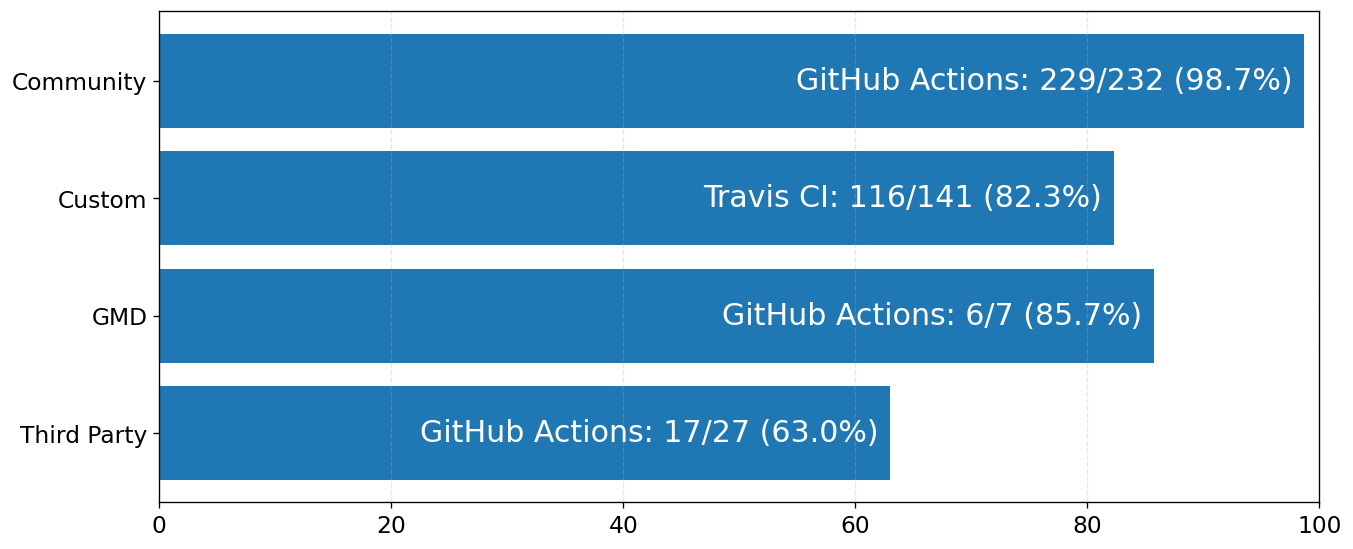

In [55]:
# ============================================================
# RQ1 / Observation 1.4 — Dominant CI provider per env style
# (single-style adopters; excludes Mixed + Real Device)
#   - Uses SAME logic as chi-square: provider present if column > 0
#   - A repo may have multiple CI providers; "dominant" = most commonly present
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT / "5_Total_Repo.csv"

OUT_DIR = ROOT / "RQ1_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq1_obs_1_4_dominant_ci_by_style.png"
OUT_CSV = OUT_DIR / "rq1_obs_1_4_dominant_ci_by_style.csv"

# -----------------------------
# Columns / Providers
# -----------------------------
ADOPT_COL = "instru_t_ci_signal"
ENV_COL   = "Exec_Env_Style"

# Use all providers you tracked (same list as your heatmap code)
ALL_PROVIDERS = {
    "GitHub Actions": "github_actions",
    "Travis CI": "travis_ci",
    "CircleCI": "circle_ci",
    "GitLab CI": "gitlab",
    "AppVeyor": "appveyor",
    "Azure Pipelines": "azure_pipelines",
    "Bitbucket Pipelines": "bitbucket",
    "Bitrise": "bitrise",
    "Cirrus CI": "cirrus",
    "Codemagic": "codemagic",
    "Semaphore": "semaphore",
}

STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party"]

# -----------------------------
# Helpers (consistent with your other scripts)
# -----------------------------
def _to_bool_str(x) -> str:
    s = str(x).strip().lower()
    return "true" if s in {"true", "1", "yes", "y", "t"} else "false"

def parse_multilabel(cell: str) -> list[str]:
    s = str(cell).strip() if cell is not None else ""
    return [p.strip() for p in s.split(",") if p.strip()] if s else []

def normalize_env_labels(raw: list[str]) -> list[str]:
    m: list[str] = []
    for x in raw:
        if x == "Emu_Community":
            m.append("Community")
        elif x == "Emu_Custom":
            m.append("Custom")
        elif x in {"GMD", "Emu_GMD"}:
            m.append("GMD")
        elif x in {"ThirdParty", "ThirdPartyDeviceLab", "Third Party", "Third-Party"}:
            m.append("Third Party")
        elif x in {"Real Device", "RealDevice"}:
            m.append("Real Device")
        else:
            m.append(x)
    return m

def single_style_label(env_cell: str) -> str:
    styles = normalize_env_labels(parse_multilabel(env_cell))
    styles = sorted(set([s for s in styles if s]))
    if not styles:
        return "Unclassified"
    if len(styles) == 1:
        return styles[0]
    return "Mixed"

def binary_present(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").fillna(0.0)
    return (x > 0).astype(int)

# -----------------------------
# Load + filter
# -----------------------------
df = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8")
df[ADOPT_COL] = df[ADOPT_COL].apply(_to_bool_str)

adopters = df[df[ADOPT_COL] == "true"].copy()
adopters["env_single"] = adopters[ENV_COL].apply(single_style_label)

# single-style only; exclude Mixed and Real Device
adopters = adopters[(adopters["env_single"] != "Mixed") & (adopters["env_single"] != "Real Device")].copy()

# Keep only the styles we plot (drop any unexpected/unknown labels)
adopters = adopters[adopters["env_single"].isin(STYLE_ORDER)].copy()
adopters["env_single"] = pd.Categorical(adopters["env_single"], categories=STYLE_ORDER, ordered=True)


# Keep only provider columns that actually exist
providers_present = {name: col for name, col in ALL_PROVIDERS.items() if col in adopters.columns}
missing_cols = [col for name, col in ALL_PROVIDERS.items() if col not in adopters.columns]
if missing_cols:
    print("[warn] Missing provider columns (ignored):", missing_cols)

if not providers_present:
    raise ValueError("No CI provider columns found in the dataset. Check column names in 5_Total_Repo.csv.")

# Build presence flags
for prov_name, col in providers_present.items():
    adopters[prov_name] = binary_present(adopters[col])

# -----------------------------
# Compute dominant provider per style
# -----------------------------
rows = []
for style in STYLE_ORDER:
    sub = adopters[adopters["env_single"] == style]
    N = int(len(sub))
    if N == 0:
        rows.append({
            "style": style,
            "N_style": 0,
            "dominant_provider": "",
            "count_present": 0,
            "pct_present": 0.0
        })
        continue

    # counts for each provider in this style
    counts = {prov: int(sub[prov].sum()) for prov in providers_present.keys()}

    # pick dominant provider: max count; tie-break by provider name (stable)
    max_count = max(counts.values()) if counts else 0
    top_providers = sorted([p for p, c in counts.items() if c == max_count])
    dominant = top_providers[0] if top_providers else ""

    pct = (max_count / N * 100.0) if N else 0.0

    rows.append({
        "style": style,
        "N_style": N,
        "dominant_provider": dominant,
        "count_present": max_count,
        "pct_present": pct
    })

res = pd.DataFrame(rows)
res.to_csv(OUT_CSV, index=False, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(res)

# -----------------------------
# Plot: one bar per style
# -----------------------------
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 14})

# Horizontal bars (percent so styles are comparable)
y = np.arange(len(STYLE_ORDER))
vals = res["pct_present"].to_numpy()

fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.barh(y, vals)

# Labels
ax.set_yticks(y)
#ax.set_yticklabels([f"{s} (N={int(res.loc[i,'N_style'])})" for i, s in enumerate(STYLE_ORDER)])
ax.set_yticklabels(STYLE_ORDER)

ax.invert_yaxis()
ax.set_xlim(0, 100)
#ax.set_xlabel("Presence rate of dominant CI provider (% of repos in style)")
#ax.set_title("Dominant CI provider by execution style (single-style adopters)")

# Annotate with provider + exact counts
for i in range(len(STYLE_ORDER)):
    prov = res.loc[i, "dominant_provider"]
    cnt = int(res.loc[i, "count_present"])
    N = int(res.loc[i, "N_style"])
    pct = float(res.loc[i, "pct_present"])

    label = f"{prov}: {cnt}/{N} ({pct:.1f}%)" if N > 0 else "N=0"

    # Put text inside the bar (near the right edge)
    x = max(1.0, pct - 1.0)  # keep inside even for small bars
    txt_color = "white" #if pct >= 55 else "black"
    ax.text(x, i, label, va="center", ha="right", fontsize=18, color=txt_color)


ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")
plt.show()


In [ ]:
## bar chart with unclassified group

[ok] Wrote CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_dominant_ci_by_style.csv
          style  N_style dominant_provider  count_present  pct_present
0     Community      232    GitHub Actions            229    98.706897
1        Custom      141         Travis CI            116    82.269504
2           GMD        7    GitHub Actions              6    85.714286
3   Third Party       27    GitHub Actions             17    62.962963
4  Unclassified       51    GitHub Actions             26    50.980392
[ok] Wrote figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\RQ1_Outputs\rq1_obs_1_4_dominant_ci_by_style.png


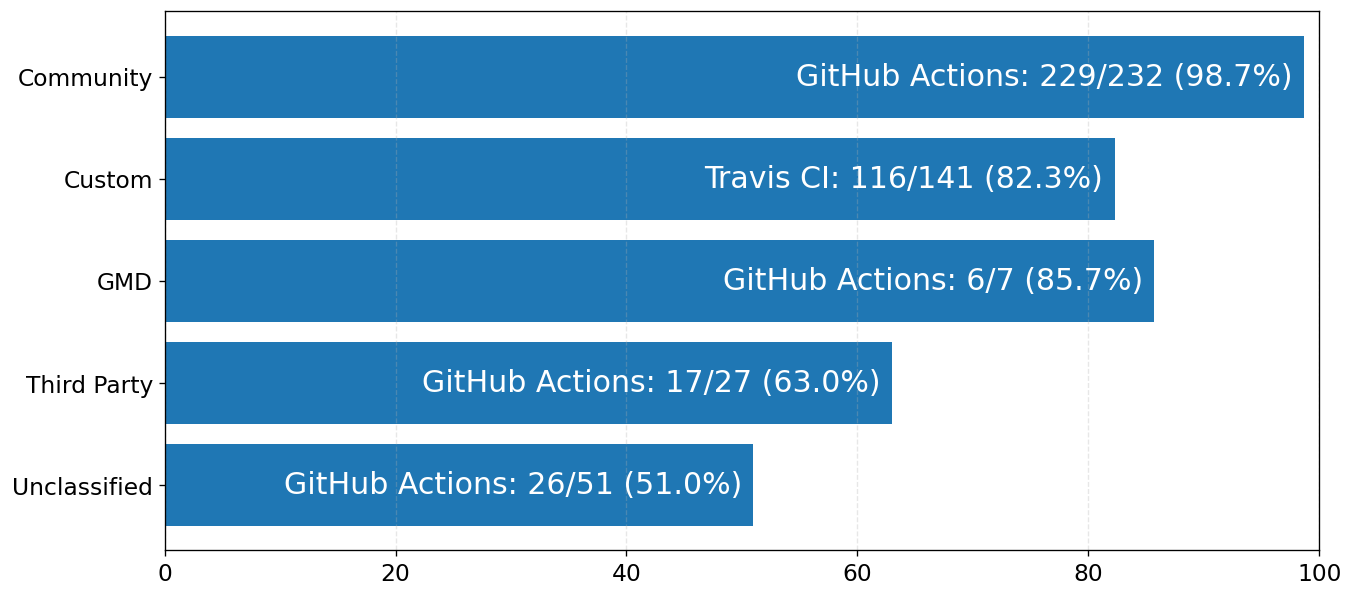

In [56]:
# ============================================================
# RQ1 / Observation 1.4 — Dominant CI provider per env style
# (single-style adopters; excludes Mixed + Real Device)
#   - Provider present if column > 0 (binary)
#   - A repo may have multiple CI providers; "dominant" = most commonly present
#   - Includes Unclassified in the plotted strata
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT / "5_Total_Repo.csv"

OUT_DIR = ROOT / "RQ1_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "rq1_obs_1_4_dominant_ci_by_style.png"
OUT_CSV = OUT_DIR / "rq1_obs_1_4_dominant_ci_by_style.csv"

# -----------------------------
# Columns / Providers
# -----------------------------
ADOPT_COL = "instru_t_ci_signal"
ENV_COL   = "Exec_Env_Style"

ALL_PROVIDERS = {
    "GitHub Actions": "github_actions",
    "Travis CI": "travis_ci",
    "CircleCI": "circle_ci",
    "GitLab CI": "gitlab",
    "AppVeyor": "appveyor",
    "Azure Pipelines": "azure_pipelines",
    "Bitbucket Pipelines": "bitbucket",
    "Bitrise": "bitrise",
    "Cirrus CI": "cirrus",
    "Codemagic": "codemagic",
    "Semaphore": "semaphore",
}

# NOTE: Unclassified is included
STYLE_ORDER = ["Community", "Custom", "GMD", "Third Party", "Unclassified"]

# -----------------------------
# Helpers
# -----------------------------
def _to_bool_str(x) -> str:
    s = str(x).strip().lower()
    return "true" if s in {"true", "1", "yes", "y", "t"} else "false"

def parse_multilabel(cell: str) -> list[str]:
    s = str(cell).strip() if cell is not None else ""
    return [p.strip() for p in s.split(",") if p.strip()] if s else []

def normalize_env_labels(raw: list[str]) -> list[str]:
    m: list[str] = []
    for x in raw:
        if x == "Emu_Community":
            m.append("Community")
        elif x == "Emu_Custom":
            m.append("Custom")
        elif x in {"GMD", "Emu_GMD"}:
            m.append("GMD")
        elif x in {"ThirdParty", "ThirdPartyDeviceLab", "Third Party", "Third-Party"}:
            m.append("Third Party")
        elif x in {"Real Device", "RealDevice"}:
            m.append("Real Device")
        else:
            m.append(x)
    return m

def single_style_label(env_cell: str) -> str:
    styles = normalize_env_labels(parse_multilabel(env_cell))
    styles = sorted(set([s for s in styles if s]))
    if not styles:
        return "Unclassified"
    if len(styles) == 1:
        return styles[0]
    return "Mixed"

def binary_present(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").fillna(0.0)
    return (x > 0).astype(int)

# -----------------------------
# Load + filter
# -----------------------------
df = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8")

for col in [ADOPT_COL, ENV_COL]:
    if col not in df.columns:
        raise ValueError(f"Missing required column '{col}' in {MAIN_CSV.name}")

df[ADOPT_COL] = df[ADOPT_COL].apply(_to_bool_str)

adopters = df[df[ADOPT_COL] == "true"].copy()
adopters["env_single"] = adopters[ENV_COL].apply(single_style_label)

# single-style only; exclude Mixed and Real Device
adopters = adopters[(adopters["env_single"] != "Mixed") & (adopters["env_single"] != "Real Device")].copy()

# Map unexpected/noisy labels into Unclassified (don’t drop them)
adopters.loc[~adopters["env_single"].isin(STYLE_ORDER), "env_single"] = "Unclassified"

# Enforce plotting order
adopters["env_single"] = pd.Categorical(adopters["env_single"], categories=STYLE_ORDER, ordered=True)

# -----------------------------
# Keep only provider columns that actually exist
# -----------------------------
providers_present = {name: col for name, col in ALL_PROVIDERS.items() if col in adopters.columns}
missing_cols = [col for _, col in ALL_PROVIDERS.items() if col not in adopters.columns]
if missing_cols:
    print("[warn] Missing provider columns (ignored):", missing_cols)

if not providers_present:
    raise ValueError("No CI provider columns found in the dataset. Check column names in 5_Total_Repo.csv.")

# Build presence flags
for prov_name, col in providers_present.items():
    adopters[prov_name] = binary_present(adopters[col])

# -----------------------------
# Compute dominant provider per style
# -----------------------------
rows = []
for style in STYLE_ORDER:
    sub = adopters[adopters["env_single"] == style]
    N = int(len(sub))

    if N == 0:
        rows.append({
            "style": style,
            "N_style": 0,
            "dominant_provider": "",
            "count_present": 0,
            "pct_present": 0.0
        })
        continue

    counts = {prov: int(sub[prov].sum()) for prov in providers_present.keys()}

    max_count = max(counts.values()) if counts else 0
    if max_count == 0:
        dominant = "None"
    else:
        top_providers = sorted([p for p, c in counts.items() if c == max_count])
        dominant = top_providers[0] if top_providers else "None"

    pct = (max_count / N * 100.0) if N else 0.0

    rows.append({
        "style": style,
        "N_style": N,
        "dominant_provider": dominant,
        "count_present": max_count,
        "pct_present": pct
    })

res = pd.DataFrame(rows)
res.to_csv(OUT_CSV, index=False, encoding="utf-8")
print(f"[ok] Wrote CSV: {OUT_CSV}")
print(res)

# -----------------------------
# Plot: one bar per style
# -----------------------------
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 14})

y = np.arange(len(STYLE_ORDER))
vals = res["pct_present"].to_numpy()

fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.barh(y, vals)

ax.set_yticks(y)
ax.set_yticklabels(STYLE_ORDER)

ax.invert_yaxis()
ax.set_xlim(0, 100)

# Annotate with provider + exact counts
for i in range(len(STYLE_ORDER)):
    prov = res.loc[i, "dominant_provider"]
    cnt = int(res.loc[i, "count_present"])
    N = int(res.loc[i, "N_style"])
    pct = float(res.loc[i, "pct_present"])

    label = f"{prov}: {cnt}/{N} ({pct:.1f}%)" if N > 0 else "N=0"

    # Put label inside bar near right edge; if bar is tiny, place just to the right
    if pct >= 12:
        x = max(1.0, pct - 1.0)
        ha = "right"
    else:
        x = pct + 1.0
        ha = "left"

    txt_color = "white" if pct >= 50 else "black"
    ax.text(x, i, label, va="center", ha=ha, fontsize=18, color=txt_color)

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches="tight")
print(f"[ok] Wrote figure: {OUT_PNG}")
plt.show()
